# **Problem Statement**
Goal:
Predict whether a customer will churn (leave the service).

Business Objective:
Identify customers at risk of churn so the company can take
retention actions like discounts or improved services.


# **Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


# **Loading Data Set**

In [ ]:
df=pd.read_csv('Copy of Telco_customer_churn.csv')

# **General Information about Data Set**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


# **Data Cleaning**

In [ ]:
print(df['Total Charges'].dtype)
df['Total Charges'].head()

float64


,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30


In [ ]:
df['Total Charges'] = pd.to_numeric(
      df['Total Charges'], errors='coerce'
    )

print("Data type of 'Total Charges' after conversion to numeric is: ",
      df['Total Charges'].dtype)

print("Number of NaN values in 'Total Charges' before cleaning:",
        df['Total Charges'].isnull().sum()
      )

df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].mean()
)

print("Number of NaN values in 'Total Charges' after cleaning:",
        df['Total Charges'].isnull().sum()
      )

Data type of 'Total Charges' after conversion to numeric is:  float64
Number of NaN values in 'Total Charges' before cleaning: 0
Number of NaN values in 'Total Charges' after cleaning: 0



# **EDA**

# Analyzing Churn Values

In [ ]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


Churn Value
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_10403/4244711789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn Value', data=df, palette='coolwarm')


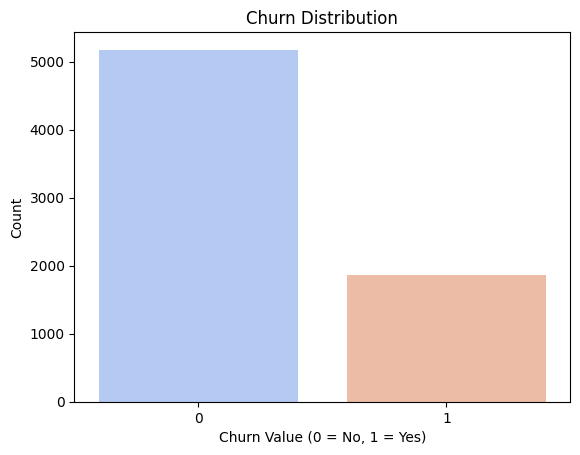

In [ ]:
print(df['Churn Value'].value_counts())
sns.countplot(x='Churn Value', data=df, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Churn Value (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

#Analyze Tenure Months Distribution

Visualize the distribution of 'Tenure Months' using a histogram or a kernel density estimate plot to understand how long customers typically stay with the service.



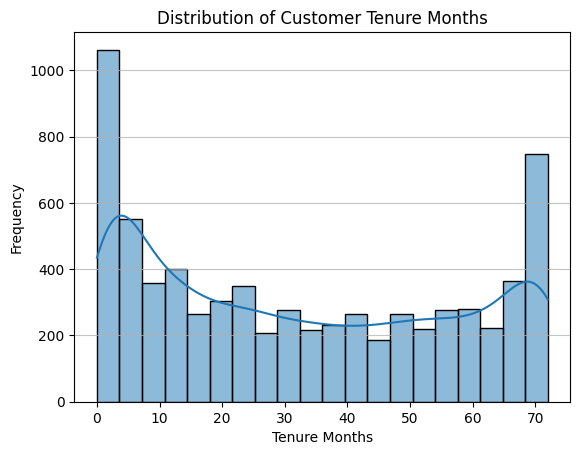

<Figure size 600x600 with 0 Axes>

In [ ]:
sns.histplot(df['Tenure Months'], kde=True, bins=20)
plt.title('Distribution of Customer Tenure Months')
plt.xlabel('Tenure Months')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.figure(figsize=(6, 6))
plt.show()

# Analyze Relationship Between Monthly Charges and Total Charges
Visualize the relationship between 'Monthly Charges' and 'Total Charges' using a scatter plot to identify any patterns or correlations.



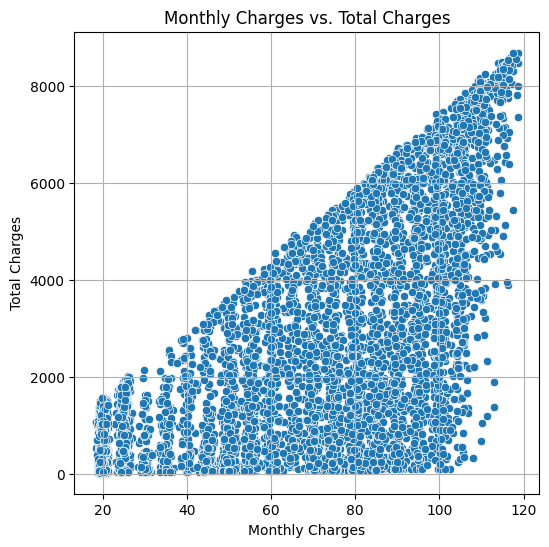

In [ ]:
df.dropna(subset=['Total Charges'], inplace=True)

plt.figure(figsize=(6, 6))
sns.scatterplot(x='Monthly Charges', y='Total Charges', data=df)
plt.title('Monthly Charges vs. Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.grid(True)
plt.show()

#Display Distribution of Contract Types

Display the distribution of 'Contract' types using a count plot or bar chart to understand the prevalence of different contract durations among customers

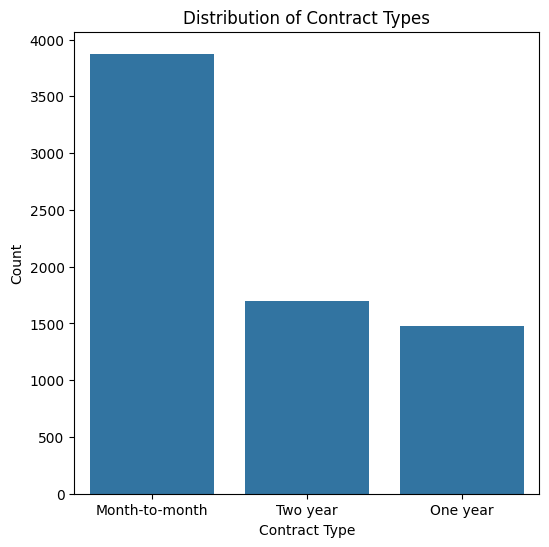

In [ ]:
plt.figure(figsize=(6, 6))
sns.countplot(x='Contract', data=df)

plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# **Summary of Key Insights and Patterns**



Based on the visualizations, the following key insights and patterns have been observed:

**1. Customer Tenure Months Distribution:**
*   The distribution of 'Tenure Months' shows a bimodal pattern, with a significant number of customers having very short tenures (0-10 months) and another large group with long tenures (above 60 months). This suggests that customers either churn early or tend to stay for a long time, with fewer customers in the middle tenure ranges.

 **2. Monthly Charges vs. Total Charges Relationship:**
*   The scatter plot reveals a strong positive correlation between 'Monthly Charges' and 'Total Charges'. As 'Monthly Charges' increase, 'Total Charges' also tend to increase. This is expected, as 'Total Charges' accumulate over time based on 'Monthly Charges'.
*   There's a noticeable spread in 'Total Charges' for lower 'Monthly Charges', indicating that some customers with low monthly bills have accumulated high total charges due to long tenure, while others with similar monthly bills have lower total charges due to shorter tenure.

**3. Distribution of Contract Types:**
*   The count plot for 'Contract' types shows that the majority of customers are on a 'Month-to-month' contract. This is followed by 'Two year' contracts, and then 'One year' contracts. This prevalence of month-to-month contracts could contribute to higher churn rates, as these contracts offer more flexibility for customers to leave the service.

# **Feature Engineering**

In [ ]:
df['Contract_Type_Num'] = df['Contract'].map({
    'Month-to-month': 1,
    'One year': 2,
    'Two year': 3
})


# Create Tenure Buckets
def tenure_bucket(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49+ months'



df['Tenure_Bucket'] = df['Tenure Months'].apply(tenure_bucket)

In [ ]:
df.shape
df.head(1)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Contract_Type_Num,Tenure_Bucket
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1,0-12 months


# **Encoding Categorical Columns**



In [ ]:

labelencoder = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Churn Reason' in categorical_cols:
    categorical_cols.remove('Churn Reason')

df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=False)
for column in categorical_cols:
    df[column] = labelencoder.fit_transform(df[column])


# **Define Features and Target**

In [ ]:
X = df.drop(["Churn Value", "Churn Label", "Churn Reason", 'Churn Score'], axis=1)
y = df["Churn Value"]

y = y.astype(int)


# **Train-Test Split**

In [ ]:
# Train-test split:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# **Model Selction and Training**

In [ ]:

# Step 3: Initialize models
log_reg = LogisticRegression(max_iter=1500, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Step 4: Train models
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# **Prediction**

In [ ]:

# Predictions
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# **Model Evaluation**

In [ ]:

# Step 6: Accuracy comparison
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("Model Accuracies:")
print(f"Logistic Regression: {acc_log:.4f}")
print(f"Random Forest:       {acc_rf:.4f}")
print(f"XGBoost:             {acc_xgb:.4f}")


Model Accuracies:
Logistic Regression: 0.7942
Random Forest:       0.7949
XGBoost:             0.7800


# **Confusion Matrix**

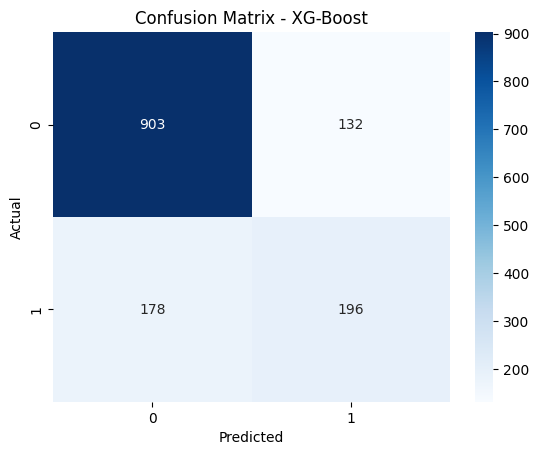

<Figure size 600x600 with 0 Axes>

In [ ]:

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XG-Boost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.figure(figsize=(6, 6))
plt.show()

# **feature Importance**

              Feature  Importance Of the Feature
23           Contract                   0.424001
12         Dependents                   0.098850
17    Online Security                   0.067768
16   Internet Service                   0.050695
20       Tech Support                   0.032009
24  Paperless Billing                   0.026484
14      Phone Service                   0.021184
13      Tenure Months                   0.021026
22   Streaming Movies                   0.020876
15     Multiple Lines                   0.019775


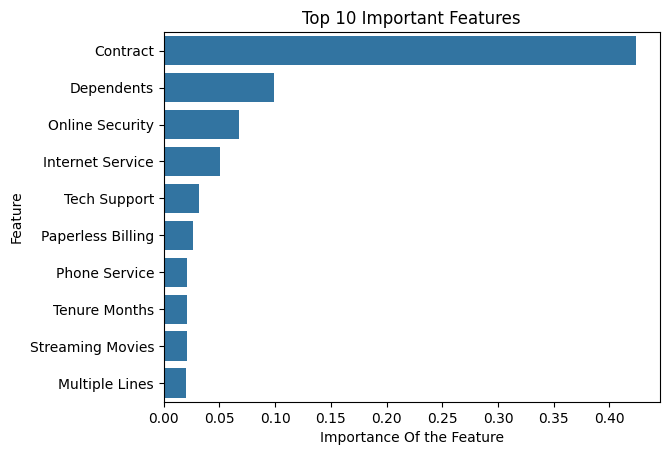

<Figure size 600x600 with 0 Axes>

In [ ]:
importances = xgb.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance Of the Feature": importances
}).sort_values(by="Importance Of the Feature", ascending=False)

print(importance_df.head(10))

sns.barplot(
    x="Importance Of the Feature",
    y="Feature",
    data=importance_df.head(10)
)

# plt.figure(figsize=(6, 6))
plt.title("Top 10 Important Features")
plt.figure(figsize=(6, 6))

plt.show()